# Project:  Circuit Breaker Vibration Signal - data exploration - 2

## **Time-domain feature extraction**:

The aim of this notebook is to demonstrate that  **simple time-domain features (e.g., mean, RMS, kurtosis) can not show clear degradation process of Circuit Breaker**

## Introdcution:
   
Circuit breakers are critical components in power systems, functioning as mechanical switching devices that protect electrical circuits from damage caused by overloads or short circuits.

Vibration-based condition monitoring is a non-invasive technique that allows us to detect the degradation process and assess the mechanical health of the equipment over time.

But, unlike other rotating machinery, the circuit breaker has a unique operational mechanism. Their vibration signals raise from dynamic switching actions (opening/closing):  These actions generate **transient, non-stationary, and non-linear** vibration signals. These characteristics make difficult for us to deal with the vibration data, for example,  **simple time-domain features (e.g., mean, RMS, kurtosis) are often insufficient or misleading due to the non-stationary nature of the data.**

The aim of this project is to explore and analyze the vibration data collected from vacuum circuit breakers (VCBs) to better understand signal patterns during degradation. This serves as a foundation for future health indicator development or predictive maintenance tasks.

## Data: "RUN-TO-FAILURE VACUUM CIRCUIT BREAKER MECHANICAL TEST DATASET"

This dataset is from ETHz High Voltage Laboratory: https://www.research-collection.ethz.ch/handle/20.500.11850/544221.



The vibration signal is meatured by accelerometer 786A. The experiment consists of three stages for each cycle: close operation, open operation, and motor charging.  For puerpose of degradation... only close operation data is used for this project. 

- Spring-operated ABB VD4 vacuum circuit breaker (VCB) Type 3612-16
- Run-to-failure data with more than 25,000 open and close operations (2,688 – 28,683 operations)
- Close and open operations are recorded in 300 kHz for 200 ms (60 000 sample points)
- Note: For this analysis, only the Close Operation signals are used, as they are most indicative of mechanical degradation.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats

from scipy.fft import fft, fftfreq
from scipy.stats import entropy

# 4.  Extract time-domain features

In [2]:
data_1 = np.load("data_2688_8745.npy")
data_2 = np.load("data_8746_18762.npy")
data_chunks_path = "data_3_chunks"
data_chunks_list = []

for file in sorted(os.listdir(data_chunks_path)):  
    if file.endswith(".npy"):
        chunk = np.load(os.path.join(data_chunks_path, file))
        data_chunks_list.append(chunk)

data_chunks = np.array(data_chunks_list)

print("data_1 shape:", data_1.shape)
print("data_2 shape:", data_2.shape)
print("data_3 shape:", data_chunks.shape)

data_1 shape: (6057, 60000)
data_2 shape: (10017, 60000)
data_3 shape: (9919, 60000)


In [3]:
data = np.vstack([data_1, data_2, data_chunks])

print("Stacked data Shape:", data.shape)

Stacked data Shape: (25993, 60000)


In [4]:
def extract_time_features(signal):
    return {
        "Mean": np.mean(signal),
        "Standard Deviation": np.std(signal),
        "RMS": np.sqrt(np.mean(signal**2)),
        "Kurtosis": scipy.stats.kurtosis(signal),
        "Skewness": scipy.stats.skew(signal),
        "Peak-to-Peak": np.ptp(signal),
        'crest_factor': np.max(signal) / np.sqrt(np.mean(signal**2)),
    }

In [5]:
feature_list = [extract_time_features(data) for data in data]

df_features = pd.DataFrame(feature_list)

df_features.shape

(25993, 7)

In [6]:
df_features.head()

,Mean,Standard Deviation,RMS,Kurtosis,Skewness,Peak-to-Peak,crest_factor
0,0.049822,0.501968,0.504435,52.500310,0.724261,17.084788,17.302891
1,0.034127,0.507467,0.508613,51.559956,0.704297,18.643392,21.093005
2,0.072029,0.513039,0.518071,47.474396,0.824875,15.576060,14.666922
3,0.056190,0.512302,0.515374,65.489814,0.909622,21.027431,20.792108
4,0.044471,0.510177,0.512112,57.420243,1.314588,17.730673,19.814297


In [7]:
df_features['Mean'].max()

0.07918270987267606

In [8]:
df_features[df_features['Mean']>0.06]

,Mean,Standard Deviation,RMS,Kurtosis,Skewness,Peak-to-Peak,crest_factor
2,0.072029,0.513039,0.518071,47.474396,0.824875,15.576060,14.666922
5,0.077069,0.554125,0.559459,94.412046,1.108133,25.229426,25.394142
48,0.072515,0.481094,0.486529,45.554263,0.606916,16.214464,18.288246
73,0.066279,0.475204,0.479804,43.557796,0.610790,13.832918,15.753517
94,0.072547,0.493313,0.498619,51.517267,0.572933,17.159601,19.110143
154,0.073922,0.527919,0.533069,58.339078,0.229856,20.758104,21.720541
225,0.079183,0.563481,0.569017,64.657212,0.725147,19.875312,18.652272
390,0.060121,0.473470,0.477272,50.534357,0.708951,15.221945,16.704454
445,0.064723,0.418405,0.423382,53.781951,0.470575,16.269327,20.014600
500,0.067530,0.498820,0.503370,51.029323,1.201737,18.134664,20.752886


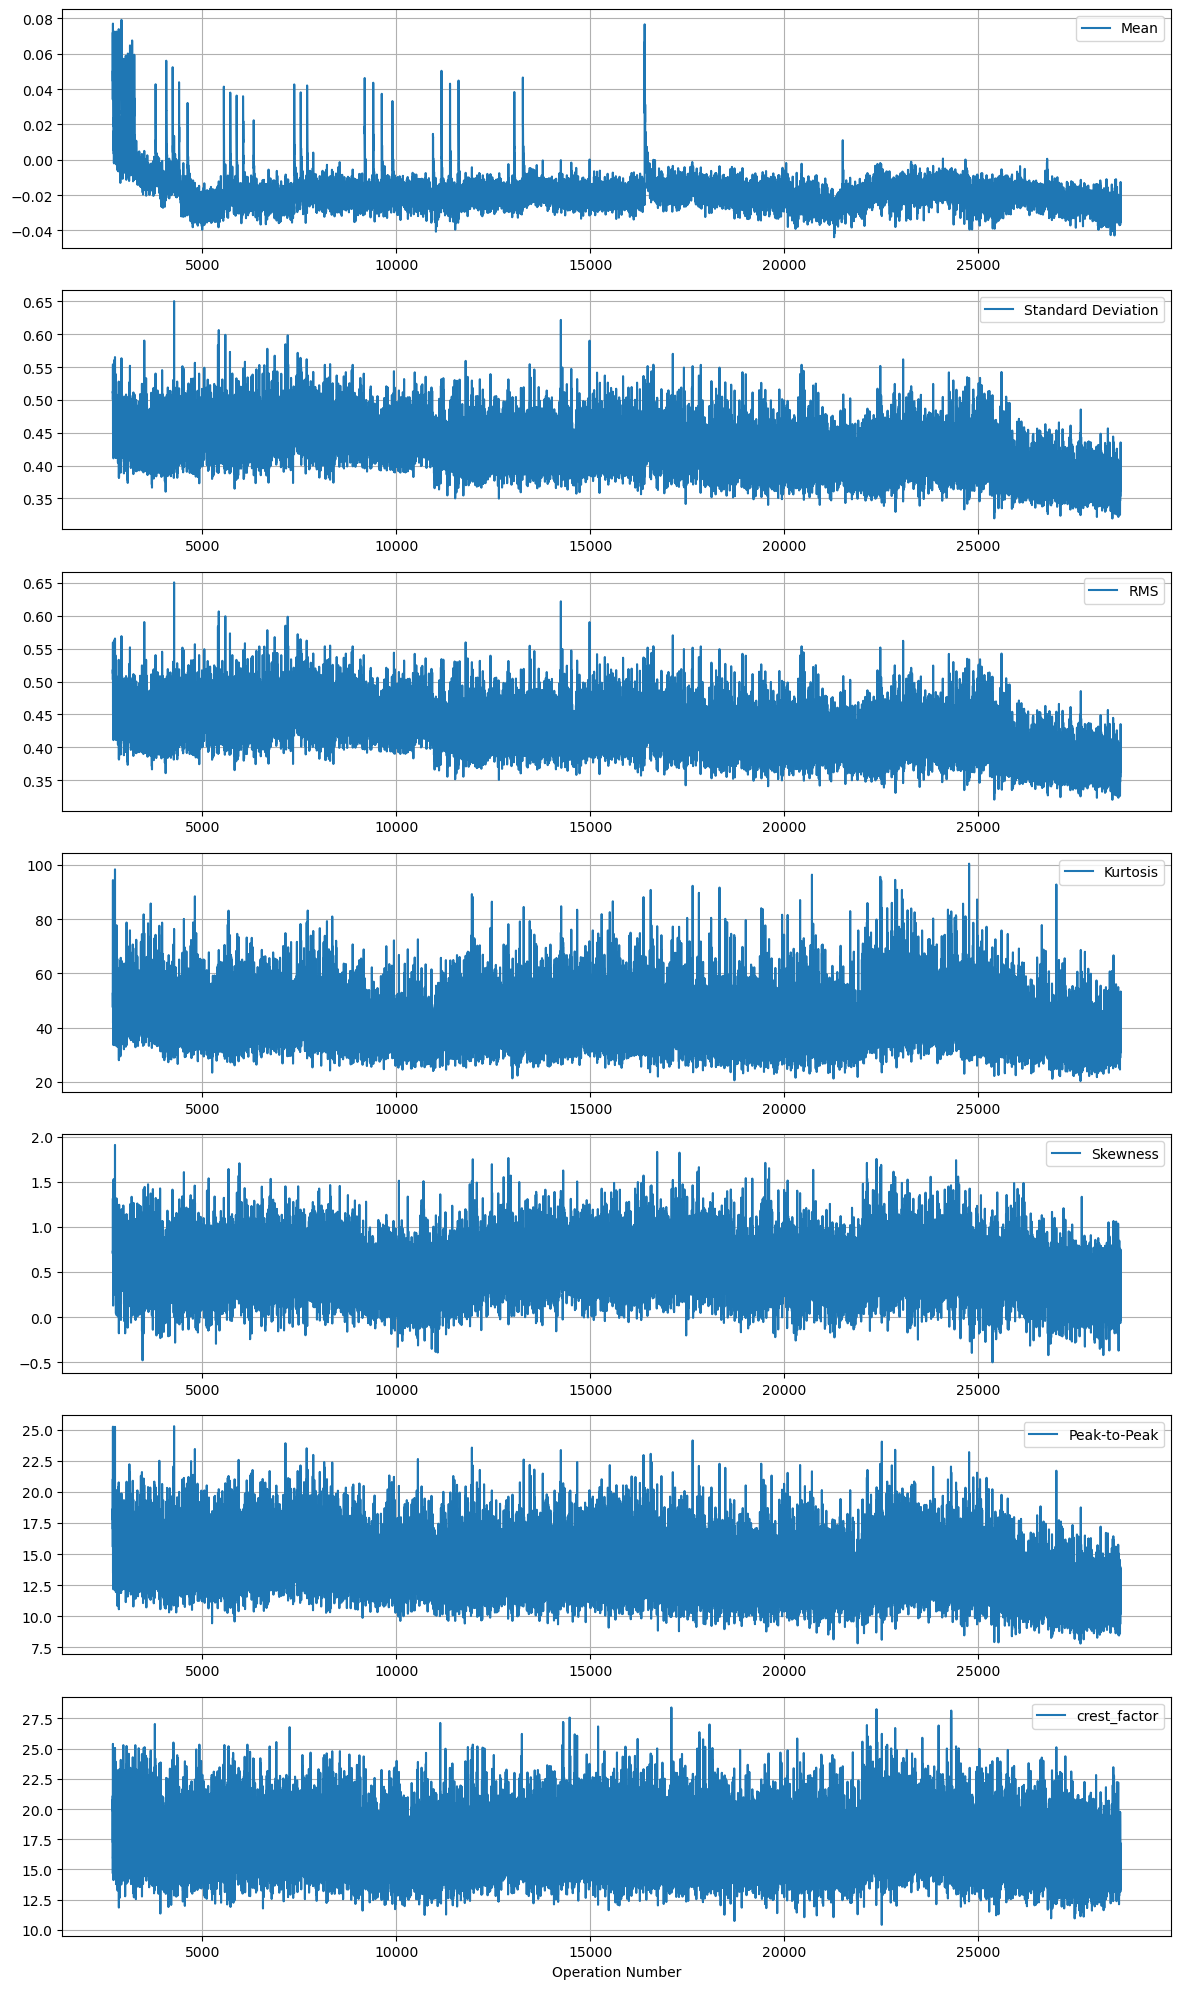

In [9]:
features = df_features.columns

operation_numbers = np.arange(2688, 28681)

plt.figure(figsize=(12, 20))
for i, feature in enumerate(features):
    plt.subplot(len(features), 1, i+1)
    plt.plot(operation_numbers, df_features[feature], label={feature})
    plt.legend()
    plt.grid()

plt.xlabel("Operation Number")
plt.tight_layout()
plt.show()
